<a href="https://colab.research.google.com/github/bhagyoday-j/ML-Assignments/blob/main/TY-open-elective/Assingments/4_Web_Page_Phishing_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Assignment : 4***
Web Page Phishig Detection

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("peyamowar/phishing-and-benign-websites")

print("Path to dataset files:", path)

100%|██████████| 858k/858k [00:00<00:00, 90.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/peyamowar/phishing-and-benign-websites/versions/1


In [4]:
import os
import pandas as pd

# List files in the dataset directory
print(os.listdir(path))

['phishing_and_benign_websites.csv']


In [6]:
csv_path = os.path.join(path, "phishing_and_benign_websites.csv")
df = pd.read_csv(csv_path)

In [7]:
print(df.head())

# Shape of the dataset
print("\nShape of dataset : ")
print(df.shape)

# Column names and data types
print("\nInfo of dataset : ")
print(df.info())

# Check for missing values
print("\nMissing values in dataset : ")
print(df.isnull().sum())

# Summary statistics
print("\nSummary statistics of dataset : ")
print(df.describe())

                                          URLs   Label
0                     http://www.wmmayhem.com/  Benign
1  http://www.ballymenaunitedyouthacademy.com/  Benign
2              http://www.brusselsgaybars.com/  Benign
3          http://www.sportsbettingtennis.net/  Benign
4                         http://www.i29.mobi/  Benign

Shape of dataset : 
(38800, 2)

Info of dataset : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38800 entries, 0 to 38799
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URLs    38800 non-null  object
 1   Label   38800 non-null  object
dtypes: object(2)
memory usage: 606.4+ KB
None

Missing values in dataset : 
URLs     0
Label    0
dtype: int64

Summary statistics of dataset : 
                                                     URLs   Label
count                                               38800   38800
unique                                              36365       2
top     http://www.sal

Label
Benign      19400
Phishing    19400
Name: count, dtype: int64


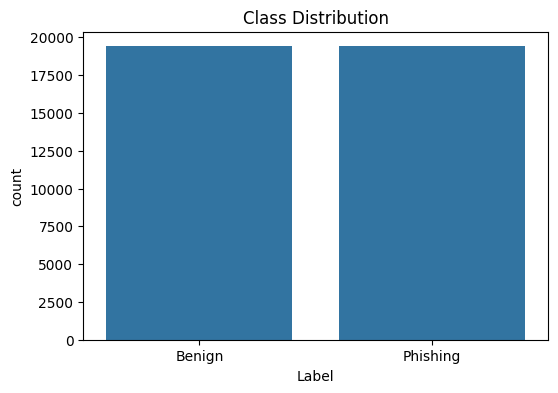

In [8]:
# Class distribution

import matplotlib.pyplot as plt
import seaborn as sns

print(df['Label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=df)
plt.title("Class Distribution")
plt.show()

In [27]:
# Label Encoding + Feature Extraction

from sklearn.preprocessing import LabelEncoder
from urllib.parse import urlparse
import pandas as pd

# Encode labels
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])  # Benign=0, Phishing=1

# Function to extract URL features
def extract_features(url):
    parsed = urlparse(url)

    return {
        'url_length': len(url),
        'domain_length': len(parsed.netloc),
        'path_length': len(parsed.path),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_special_chars': sum(not c.isalnum() for c in url),
        'has_https': 1 if parsed.scheme == 'https' else 0
    }

# def extract_features(url):
#     parsed = urlparse(url)

#     return {
#         'url_length': len(url),
#         'domain_length': len(parsed.netloc),
#         'path_length': len(parsed.path),
#         'num_dots': url.count('.'),
#         'num_hyphens': url.count('-'),
#         'num_digits': sum(c.isdigit() for c in url),
#         'num_special_chars': sum(not c.isalnum() for c in url)
#     }

# Create feature dataframe
features_df = pd.DataFrame(df['URLs'].apply(extract_features).tolist())

print(features_df.head())

print("\nShape of extracted features:")
print(features_df.shape)

   url_length  domain_length  path_length  num_dots  num_hyphens  num_digits  \
0          24             16            1         2            0           0   
1          43             35            1         2            0           0   
2          31             23            1         2            0           0   
3          35             27            1         2            0           0   
4          20             12            1         2            0           2   

   num_special_chars  has_https  
0                  6          0  
1                  6          0  
2                  6          0  
3                  6          0  
4                  6          0  

Shape of extracted features:
(38800, 8)


In [29]:
# Train-Test Split + Feature Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = features_df
y = df['Label']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

Training set shape: (31040, 8)
Testing set shape: (7760, 8)

Feature scaling completed.


In [30]:
# Train Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


===== MODEL EVALUATION =====
Accuracy  : 0.8807
Precision : 0.9128
Recall    : 0.8418
F1 Score  : 0.8758
ROC-AUC   : 0.9499


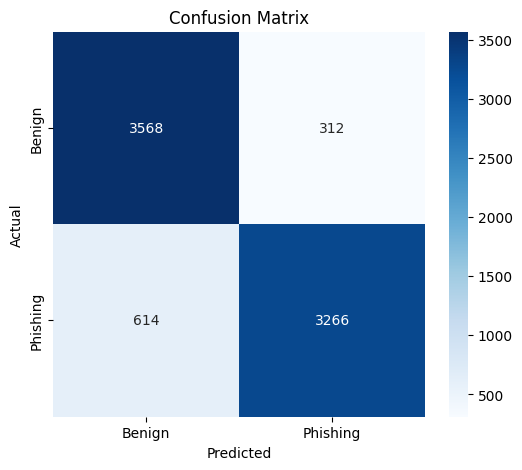

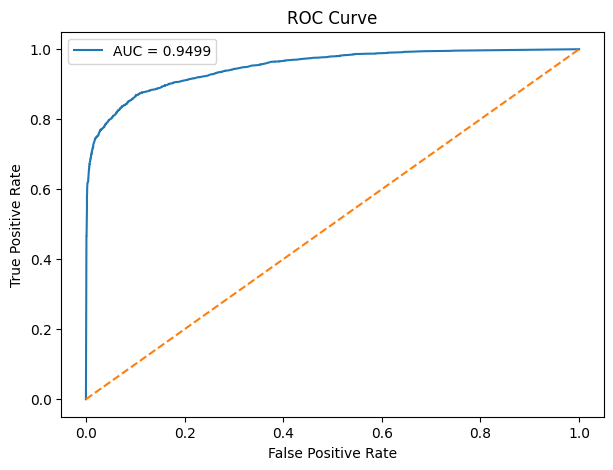

In [31]:
# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== MODEL EVALUATION =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Benign', 'Phishing'],
            yticklabels=['Benign', 'Phishing'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [36]:
# User Input Prediction

from urllib.parse import urlparse
import pandas as pd

def extract_features(url):
    parsed = urlparse(url)

    return {
        'url_length': len(url),
        'domain_length': len(parsed.netloc),
        'path_length': len(parsed.path),
        'num_dots': url.count('.'),
        'num_hyphens': url.count('-'),
        'num_digits': sum(c.isdigit() for c in url),
        'num_special_chars': sum(not c.isalnum() for c in url),
        'has_https': 1 if parsed.scheme == 'https' else 0
    }

# Take URL input
user_url = input("Enter Website URL: ")

# Extract features
user_features = pd.DataFrame([extract_features(user_url)])

# Scale features
user_features_scaled = scaler.transform(user_features)

# Predict
prediction = rf_model.predict(user_features_scaled)[0]
probability = rf_model.predict_proba(user_features_scaled)[0]

# Display result
predicted_label = le.inverse_transform([prediction])[0]

#print("\nPrediction:", predicted_label.upper())
print("\nPrediction:", str(predicted_label).upper())

print(f"Benign Probability  : {probability[0]*100:.2f}%")
print(f"Phishing Probability: {probability[1]*100:.2f}%")

Enter Website URL: bmjapps.in

Prediction: 1
Benign Probability  : 34.22%
Phishing Probability: 65.78%


**Conclusion**

A Random Forest Classification model was developed for phishing website detection using URL-based features such as URL length, domain length, number of dots, digits, special characters, and HTTPS usage. The dataset consisted of 38,800 website URLs equally distributed between benign and phishing classes.

The trained model achieved an accuracy of **88.07%**, indicating that it correctly classified most websites. The precision score of **91.28%** shows that when the model predicts a website as phishing, it is correct most of the time. The recall score of **84.18%** indicates that the model successfully identifies a large proportion of actual phishing websites. The F1 score of **87.58%** demonstrates a good balance between precision and recall.

The ROC-AUC score of **94.99%** indicates excellent discrimination capability between phishing and benign websites. The confusion matrix and ROC curve further confirm the effectiveness of the model.

Overall, the Random Forest classifier provides strong performance for phishing website detection and can be used as a reliable tool for identifying potentially malicious websites based on URL characteristics.
